# The Black-Scholes Hull-White model (BSHW)

## Definition

## Pricing European Call and Put Options

1. We have $\mathbf{X}_t := \begin{bmatrix}
           S_t \\
           r_t \\
         \end{bmatrix}$ <br><br>
         
1. The SDE under the $\mathbb{Q}$ become $$\begin{align*} 
dr_t &= \lambda(\theta_t -r_t ) dt + \sigma_r r_t dW_r(t) \\ 
dS_t &= r_t  S_t dt + \sigma_s S_t dW_s(t) \\ 
\end{align*}$$ <br>
Where :
    * $W_r(t)$ and $W_s(t)$ are correlated brownian motions with $dW_r(t) \times dW_s(t) = \rho_{s,r}dt$
    * parameters $\sigma_r$ and $\sigma_s$ represent the volatility of the interest rate and stock 
    <br><br>

1. In practice the parameters $\sigma_r$ and $\sigma_s$ are time dependent calibrated from instruments

1. The interest rate parameters can be calibrated from caps, floor and options then we move to calibrate the rest
    
1. In terms of independent brownian motion we have :
$$\begin{align*} 
\begin{bmatrix} dr_t \\ \frac{dS_t}{S_t}  \end{bmatrix} = \begin{bmatrix} \lambda (\theta_1 - r_t) \\ r_t  \end{bmatrix} dt + \begin{bmatrix} \sigma_r & 0 \\ \sigma_s \rho_{s,r} & \sigma_s \sqrt{1 - \rho_{s,r}^2}   \end{bmatrix} \begin{bmatrix} d\tilde{W_r}(t) \\ d\tilde{W_s}(t) \end{bmatrix}
\end{align*}$$ <br>

1. In essence this is the classical Black-Scholes set up but here the interest rate follows the HW1F process

1. By applying the transformation into log coordinate $X_t = log S_t$ the model now reads <br><br>
$$\begin{align*} 
dr_t &= \lambda(\theta_t -r_t ) dt + \sigma_r r_t dW^{(r)}_t \\ 
dX_t &= \left(r_t -  \dfrac{1}{2}\sigma_s^2 \right)dt + \sigma_s dW^{(s)}_t \\ 
\end{align*}$$ <br><br>

1. It is easy to see that model satistfies the **affinity** conditions hence the **characteristic function**  can be easily derived

1. For the state vector  $\mathbf{X}_t := \begin{bmatrix} X_t \\ r_t \\ \end{bmatrix}$ 
The discounted characteristic function with $\mathbf{u} = \begin{bmatrix} u \\ 0 \\ \end{bmatrix}$ and $\tau := T-t$ reads <br><br>
$$\boxed{\phi_{BSHW}(u;t,T) = \exp \left[ A \left(u,\tau\right) + B(u,\tau) X_t  + C(u, \tau)r_t \right]}$$
<br><br>
with final condition $\phi_{BSHW}(u;T,T) = \exp (iuX_T)$

1. the functions $ A, B$ and $C$ are found to be 
$$\begin{align*} 
A(u,\tau) &= \dfrac{1}{2}\sigma_s^2 iu(iu-1)\tau + \dfrac{\rho \sigma_s\sigma_r}{\lambda}iu(iu-1) \left( \tau + \dfrac{1}{\lambda}(e^{-\lambda\tau}-1)\right) + \dfrac{\sigma_r^2}{4\lambda^3}(i+u)^2  \left(3 + e^{-2\lambda\tau} - 4e^{-\lambda\tau} - 2\lambda \tau \right) + \lambda \int_0^\tau \theta(T- z)C(u,z)dz\\
B(u,\tau) &= iu \\
C(u,\tau) &= \dfrac{1}{\lambda}(iu -1)(1- e^{\lambda\tau})\\
\end{align*}$$ <br><br>


1. The fundamental theorem of asset pricing states that the price at time $t_0$ of any contingent claims with payoff $H(T, S)$ is given by <br><br>
$$\boxed{V(t_0, S) = \mathbb{E^{Q}} \left[ \dfrac{1}{M(T)}  H(T, S) | \mathscr{F}(t_0) \right]  }  $$<br><br>

1. By Switching to the forward measure $\mathbb{T}$ with numeraire $P(t_0,T)$ we can eliminate stochastic discount and we have <br><br>
$$V(t_0, S) =  P(t_0,T) \mathbb{E^{T}} \left[H(T, S) \right]$$ <br><br>

1. Let's define the Forward stock price $$\boxed{S_F(t,T) := \dfrac{S(t)}{P(t,T)}}$$
    * Clearly under $\mathbb{T}$ the forward stock price is a martingale
    * Also Note that $S_F(T,T) = S(T)$ so for european types option we may as well work with the forward price <br><br><br> 
    
1. By applying ito's lemma we find <br> <br> 
$$\boxed{dS_F(t,T) = \sigma_sS_F(t,T)dW^{\mathbb{T}}_s(t) - \sigma_r S_F(t,T) B_r(t,T) dW^{\mathbb{T}}_r(t)} $$
<br>
there is no $dt$ term hence we see that it is a martingale. The proof of the dynamic of can be found in the next section 
 <br><br>

 1. <font color='Red'>Note the $B_r$ is coming from the dinamics of the zero coupon bond $dP(t,T)$ when we are in the hull-white model </font>

1. The above can be simplified event more using $$a W_1(t) + b W_2(t) = \sqrt{a^2 + b^2 + 2ab \rho_{1,2}} \times W_3(t)$$
where :
    * $W_1(t)$ and $W_2(t)$ are brownian motions with correlation $\rho_{1,2}$ 
    * $a$ and $b$ are positive constant
    * $W_3(t)$ is also a brownian motion
This is true only in the distribution sense. This won't work for path dependent 
    <br><br>
    
1. Hence we have<br>  
$$dS_F(t,T) = \sigma_F(t)S_F(t,T) dW_F(t)$$ <br>
where $\sigma_F(t) = \sqrt{\sigma_s^2 + \sigma_r^2 B_r(t,T)^2 -  2\rho\sigma_s\sigma_r B_r(t,T)}$  <br><br>

1. to Price option because we have $S_F(T,T) = S(T)$ we can use black shcholes <br>
The black formula is $$C = P(0,T)\times Blk(S_F,K,\sigma_c,T)$$
where $$\sigma_c^2 = \dfrac{1}{T-t_0} \int_{t_0}^T \sigma_F^2(z) dz$$ <br><br>

1. The parameter $\sigma_c$ is often called effective parameter <br><br>

1. Note in this model there would be flat vol for every strike

### Example finding the dynamic of forward stock price $S_F$ under $\mathbb{T}$

#### code used for ito lemma and measure change 

In [1]:
from sympy import symbols, expand, factor, diff, E, Function, maximum, Derivative, collect, simplify , Matrix, log, apart, Equality
import sympy
def ito_lemma_3D (
G = Function('G')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
    
X_1 = symbols('X_1'),
X_2 = symbols('X_2'),
X_3 = symbols('X_3'),
    
dW_1 = symbols('dW_1'),
dW_2 = symbols('dW_2'),
dW_3 = symbols('dW_3'),   
    
dB_1 = symbols('dB_1'),
dB_2 = symbols('dB_2'),
dB_3 = symbols('dB_3'),  
    
ρ_12 = symbols('ρ_12'),
ρ_13 = symbols('ρ_13'),
ρ_23 = symbols('ρ_23'), 
       
Θ_1 = Function('Θ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_2 = Function('Θ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_3 = Function('Θ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),

Ψ_1 = Function('Ψ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_2 = Function('Ψ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_3 = Function('Ψ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),

factorize_it = False,
dependent_brownian = False
):


    dt, t = symbols(' dt,  t')

    Θ = Matrix([ 
          [Θ_1] ,
          [Θ_2] ,
          [Θ_3 ] 
    ])

    Ψ = Matrix([ 
          [ Ψ_1,  0      ,  0      ] ,
          [ 0      , Ψ_2 ,  0      ]  ,
          [ 0      ,   0     , Ψ_3 ] 
    ])

    dW = Matrix([ 
          [dW_1] ,
          [dW_2 ],  
          [dW_3 ]
    ])

    dB = Matrix([ 
          [dB_1] ,
          [dB_2 ] ,
          [dB_3 ]  
    ])

    C = Matrix([ 
          [1, ρ_12, ρ_13] ,
          [ρ_12, 1, ρ_23] ,
          [ρ_13 ,ρ_23, 1]
    ])

    L = C.cholesky(hermitian=False)
    Σ = Ψ*L
    
    print("The system of SDE is : ")
    if dependent_brownian :
        dX = Θ * dt + Ψ*dW
        display(dX)
        dX_1 = dX[0]
        dX_2 = dX[1]
        dX_3 = dX[2]
        
        
    else:
        dX = Θ * dt + Ψ*L*dB
        display(dX)
        dX_1 = dX[0]
        dX_2 = dX[1]
        dX_3 = dX[2]



    


    G_t = diff(G, t)

    G_x1 = diff(G, X_1) 
    G_x2 = diff(G, X_2) 
    G_x3 = diff(G, X_3) 

    G_x1_x1 = diff(G_x1, X_1) 
    G_x2_x2 = diff(G_x2, X_2)
    G_x3_x3 = diff(G_x3, X_3)

    G_x1_x2 = diff(G_x1, X_2) 
    G_x1_x3 = diff(G_x1, X_3) 

    G_x2_x1 = diff(G_x2, X_1) 
    G_x2_x3 = diff(G_x2, X_3) 

    G_x3_x1 = diff(G_x3, X_1) 
    G_x3_x2 = diff(G_x3, X_2) 


    dG = G_t + G_x1 * dX_1  + G_x2 * dX_2 +  G_x3 * dX_3  +  1/2* (G_x1_x1 * dX_1 * dX_1 + 
                                                                   G_x2_x2 * dX_2 * dX_2 + 
                                                                   G_x3_x3 * dX_3 * dX_3 + 

                                                                   G_x1_x2 * dX_1 * dX_2 +
                                                                   G_x2_x1 * dX_2 * dX_1 +  

                                                                   G_x1_x3 * dX_1 * dX_3 +
                                                                   G_x3_x1 * dX_3 * dX_1 +

                                                                   G_x2_x3 * dX_2 * dX_3 +
                                                                   G_x3_x2 * dX_3 * dX_2                                                       
                                                                  )  

    dG = (
    expand (dG)
    .subs(dB_1**2, dt)
    .subs(dB_2**2, dt)
    .subs(dB_3**2, dt)
    .subs(dB_1*dt, 0)
    .subs(dB_2*dt, 0)
    .subs(dB_3*dt, 0)
    .subs(dB_1*dB_2, ρ_12*dt)
    .subs(dB_1*dB_3, ρ_13*dt)
    .subs(dB_2*dB_3, ρ_23*dt)
    .subs(dt**2,0)
    .subs(dW_1**2, dt)
    .subs(dW_2**2, dt)
    .subs(dW_3**2, dt)
    .subs(dW_1*dt, 0)
    .subs(dW_2*dt, 0)
    .subs(dW_3*dt, 0)
    .subs(dW_1*dW_2, ρ_12*dt)
    .subs(dW_1*dW_3, ρ_13*dt)
    .subs(dW_2*dW_3, ρ_23*dt)
    .subs(dt**2,0)
    .subs(G, symbols('G'))
    )
    
    return collect(dG , (dt,dB_1,dB_2, dB_3, dW_1,dW_2, dW_3, G ) )  if factorize_it else dG



def change_measure_from_X1_to_X2 (
    
X_1 = symbols('X_1'),
X_2 = symbols('X_2'),
X_3 = symbols('X_3'),
    
dW_1 = symbols('dW_1'),
dW_2 = symbols('dW_2'),
dW_3 = symbols('dW_3'),   
    
dB_1 = symbols('dB_1'),
dB_2 = symbols('dB_2'),
dB_3 = symbols('dB_3'),  
    
ρ_12 = symbols('ρ_12'),
ρ_13 = symbols('ρ_13'),
ρ_23 = symbols('ρ_23'), 
       
Θ_1 = Function('Θ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_2 = Function('Θ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_3 = Function('Θ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),

Ψ_1 = Function('Ψ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_2 = Function('Ψ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_3 = Function('Ψ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3'))

):
    dt, t = symbols(' dt,  t')
    
    dX = Matrix([ 
          [symbols('dX_1')] ,
          [symbols('dX_2')] ,
          [symbols('dX_3')] 
    ])

    Θ = Matrix([ 
          [Θ_1] ,
          [Θ_2] ,
          [Θ_3 ] 
    ])

    Ψ = Matrix([ 
          [ Ψ_1,  0      ,  0      ] ,
          [ 0      , Ψ_2 ,  0      ]  ,
          [ 0      ,   0     , Ψ_3 ] 
    ])

    dW = Matrix([ 
          [dW_1] ,
          [dW_2 ],  
          [dW_3 ]
    ])

    dB = Matrix([ 
          [dB_1] ,
          [dB_2 ] ,
          [dB_3 ]  
    ])

    C = Matrix([ 
          [1, ρ_12, ρ_13] ,
          [ρ_12, 1, ρ_23] ,
          [ρ_13 ,ρ_23, 1]
    ])

    L = C.cholesky(hermitian=False)
    

    Σ = Ψ*L

    Σ_1 =  Σ.row(0)
    Σ_2 =  Σ.row(1)
    Σ_3 =  Σ.row(2)

    A = (  Σ_2 / X_2 - Σ_1 / X_1 )
    B = Σ_3 * A.T 

    Θ_new = Θ  + Σ * (  Σ_2 / X_2 - Σ_1 / X_1 ).T

    dX_new =  Θ_new *dt +  Σ * dB

    dX_new = (
    simplify(expand (dX_new)
    .subs(dB_1**2, dt)
    .subs(dB_2**2, dt)
    .subs(dB_3**2, dt)
    .subs(dB_1*dt, 0)
    .subs(dB_2*dt, 0)
    .subs(dB_3*dt, 0)
    .subs(dB_1*dB_2, ρ_12*dt)
    .subs(dB_1*dB_3, ρ_13*dt)
    .subs(dB_2*dB_3, ρ_23*dt)
    .subs(dt**2,0)
    .subs(dW_1**2, dt)
    .subs(dW_2**2, dt)
    .subs(dW_3**2, dt)
    .subs(dW_1*dt, 0)
    .subs(dW_2*dt, 0)
    .subs(dW_3*dt, 0)
    .subs(dW_1*dW_2, ρ_12*dt)
    .subs(dW_1*dW_3, ρ_13*dt)
    .subs(dW_2*dW_3, ρ_23*dt)
    ))
    
    expression = Equality(dX, dX_new)
    display(expression)

    return  dX_new
    
    
    
    

#### Change measure to the forward measure 

In [2]:
dt, t, r = symbols(' dt,  t, r_t')

X_1 = M_t = symbols('M_t') 
X_2 =  P_t = symbols('P_t')
X_3 = S_t = symbols('S_t')

dW_1 = 0
dW_2 = symbols('dW_P')
dW_3 =  symbols('dW_s')

dB_1 = 0
dB_2 = symbols('dB_p')
dB_3 = symbols('dB_s')

ρ_12 = 0
ρ_13 = 0
ρ_23 = symbols('ρ')

Θ_1 = r * M_t 
Θ_2 = r * P_t 
Θ_3 =  r * S_t

Ψ_1 = 0 
Ψ_2 = symbols('η') * symbols('β') * P_t 
Ψ_3 = S_t * symbols('σ')


res = change_measure_from_X1_to_X2 (
X_1 = X_1,
X_2 = X_2,
X_3 = X_3,
    
dW_1 = dW_1,
dW_2 = dW_2,
dW_3 = dW_3,   
    
dB_1 = dB_1,
dB_2 = dB_2,
dB_3 = dB_3,  
    
ρ_12 = ρ_12,
ρ_13 = ρ_13,
ρ_23 = ρ_23, 
       
Θ_1 = Θ_1,
Θ_2 = Θ_2,
Θ_3 = Θ_3,

Ψ_1 = Ψ_1,
Ψ_2 = Ψ_2,
Ψ_3 = Ψ_3,
)

Eq(Matrix([
[dX_1],
[dX_2],
[dX_3]]), Matrix([
[                                                  M_t*dt*r_t],
[                      P_t*(dB_p*β*η + dt*r_t + dt*β**2*η**2)],
[S_t*(dB_p*ρ*σ + dB_s*σ*sqrt(1 - ρ**2) + dt*r_t + dt*β*η*ρ*σ)]]))

#### use ito lemma to find the dynamic of $S_F$

In [3]:
η = symbols('η')
B_r = symbols('B_r')
σ = symbols('σ')

X_1 = M_t = symbols('M_t') 
X_2 =  P_t = symbols('P_t')
X_3 = S_t = symbols('S_t')

dW_1 = 0
dW_2 = symbols('dW_P')
dW_3 =  symbols('dW_s')

dB_1 = 0
dB_2 = symbols('dB_p')
dB_3 = symbols('dB_s')

ρ_12 = 0
ρ_13 = 0
ρ_23 = symbols('ρ')

Θ_1 = r * M_t 
Θ_2 = ( r  +  η**2 * B_r **2 ) * P_t 
Θ_3 =  S_t * (  r + ρ_23 * η * σ * B_r   )

Ψ_1 = 0 
Ψ_2 = symbols('η') * B_r * P_t 
Ψ_3 = σ * S_t 

G =S_t / P_t

dG = ito_lemma_3D ( 
    
X_1 = X_1,
X_2 = X_2,
X_3 = X_3,
    
G = G,

dW_1 = dW_1,
dW_2 = dW_2,
dW_3 = dW_3,   
    
dB_1 = dB_1,
dB_2 = dB_2,
dB_3 = dB_3,  
    
ρ_12 = ρ_12,
ρ_13 = ρ_13,
ρ_23 = ρ_23, 
       
Θ_1 = Θ_1,
Θ_2 = Θ_2,
Θ_3 = Θ_3,

Ψ_1 = Ψ_1,
Ψ_2 = Ψ_2,
Ψ_3 = Ψ_3,

    factorize_it = True, dependent_brownian=True
)


print("\n The dynamic of S_F is")
dG

The system of SDE is : 


Matrix([
[                                 M_t*dt*r_t],
[B_r*P_t*dW_P*η + P_t*dt*(B_r**2*η**2 + r_t)],
[      S_t*dW_s*σ + S_t*dt*(B_r*η*ρ*σ + r_t)]])


 The dynamic of S_F is


-B_r*G*dW_P*η + G*dW_s*σ

### Pricing Options via cos method in BSHW model

C:\Users\wb548956\AppData\Local\Temp/ipykernel_28564/2022336857.py:21: DeprecationWarning: `np.complex` is a deprecated alias for the builtin `complex`. To silence this warning, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  i   = np.complex(0.0,1.0)
C:\Users\wb548956\AppData\Local\Temp/ipykernel_28564/2022336857.py:46: DeprecationWarning: `np.complex` is a deprecated alias for the builtin `complex`. To silence this warning, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  i = np.complex(0.0,1.0)
C:\Users\wb548956\AppData\Local\Temp/i

0.25950814866573263


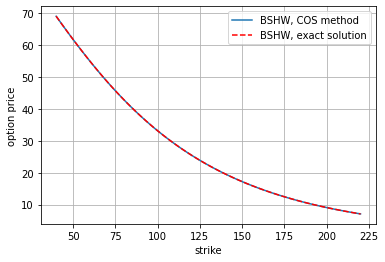

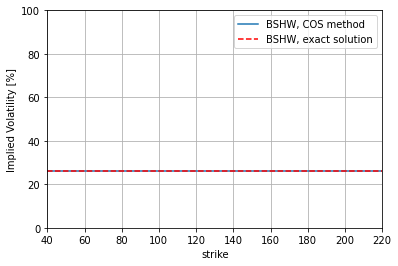

In [4]:
#%%
"""
Created on Thu Jan 04 2019
The BSHW model and implied volatilities obtained with the COS method and comparisons 
against a factorized 1D case where the implied volatilities are known analytically

This code is purely educational and comes from "Financial Engineering" course by L.A. Grzelak
The course is based on the book “Mathematical Modeling and Computation
in Finance: With Exercises and Python and MATLAB Computer Codes”,
by C.W. Oosterlee and L.A. Grzelak, World Scientific Publishing Europe Ltd, 2019.
@author: Lech A. Grzelak
"""
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.stats as st
import enum 
import scipy.optimize as optimize

# set i= imaginary number
i   = np.complex(0.0,1.0)

# time-step needed for differentiation
dt = 0.0001
 
# This class defines puts and calls
class OptionType(enum.Enum):
    CALL = 1.0
    PUT = -1.0   

def CallPutOptionPriceCOSMthd_StochIR(cf,CP,S0,tau,K,N,L,P0T):
    # cf   - characteristic function as a functon, in the book denoted as \varphi
    # CP   - C for call and P for put
    # S0   - Initial stock price
    # tau  - time to maturity
    # K    - list of strikes
    # N    - Number of expansion terms
    # L    - size of truncation domain (typ.:L=8 or L=10)  
    # P0T  - zero-coupon bond for maturity T.
        
    # reshape K to a column vector
    if K is not np.array:
        K = np.array(K).reshape([len(K),1])
    
    #assigning i=sqrt(-1)
    i = np.complex(0.0,1.0) 
    x0 = np.log(S0 / K)   
    
    # truncation domain
    a = 0.0 - L * np.sqrt(tau)
    b = 0.0 + L * np.sqrt(tau)
    
    # sumation from k = 0 to k=N-1
    k = np.linspace(0,N-1,N).reshape([N,1])  
    u = k * np.pi / (b - a);  

    # Determine coefficients for Put Prices  
    H_k = CallPutCoefficients(OptionType.PUT,a,b,k)   
    mat = np.exp(i * np.outer((x0 - a) , u))
    temp = cf(u) * H_k 
    temp[0] = 0.5 * temp[0]    
    value = K * np.real(mat.dot(temp))     
    
    # we use call-put parity for call options
    if CP == OptionType.CALL:
        value = value + S0 - K * P0T
        
    return value

# Determine coefficients for Put Prices 
def CallPutCoefficients(CP,a,b,k):
    if CP==OptionType.CALL:                  
        c = 0.0
        d = b
        coef = Chi_Psi(a,b,c,d,k)
        Chi_k = coef["chi"]
        Psi_k = coef["psi"]
        if a < b and b < 0.0:
            H_k = np.zeros([len(k),1])
        else:
            H_k      = 2.0 / (b - a) * (Chi_k - Psi_k)  
    elif CP==OptionType.PUT:
        c = a
        d = 0.0
        coef = Chi_Psi(a,b,c,d,k)
        Chi_k = coef["chi"]
        Psi_k = coef["psi"]
        H_k      = 2.0 / (b - a) * (- Chi_k + Psi_k)               
    
    return H_k    

def Chi_Psi(a,b,c,d,k):
    psi = np.sin(k * np.pi * (d - a) / (b - a)) - np.sin(k * np.pi * (c - a)/(b - a))
    psi[1:] = psi[1:] * (b - a) / (k[1:] * np.pi)
    psi[0] = d - c
    
    chi = 1.0 / (1.0 + np.power((k * np.pi / (b - a)) , 2.0)) 
    expr1 = np.cos(k * np.pi * (d - a)/(b - a)) * np.exp(d)  - np.cos(k * np.pi 
                  * (c - a) / (b - a)) * np.exp(c)
    expr2 = k * np.pi / (b - a) * np.sin(k * np.pi * 
                        (d - a) / (b - a))   - k * np.pi / (b - a) * np.sin(k 
                        * np.pi * (c - a) / (b - a)) * np.exp(c)
    chi = chi * (expr1 + expr2)
    
    value = {"chi":chi,"psi":psi }
    return value
    
# Black-Scholes Call option price
def BS_Call_Option_Price(CP,S_0,K,sigma,tau,r):
    if K is list:
        K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) 
    * tau) / float(sigma * np.sqrt(tau))
    d2    = d1 - sigma * np.sqrt(tau)
    if CP == OptionType.CALL:
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * tau)
    elif CP == OptionType.PUT:
        value = st.norm.cdf(-d2) * K * np.exp(-r * tau) - st.norm.cdf(-d1)*S_0
    return value

# Implied volatility method
def ImpliedVolatilityBlack76(CP,marketPrice,K,T,S_0):
    func = lambda sigma: np.power(BS_Call_Option_Price(CP,S_0,K,sigma,T,0.0) - marketPrice, 1.0)
    impliedVol = optimize.newton(func, 0.2, tol=1e-9)
    #impliedVol = optimize.brent(func, brack= (0.05, 2))
    return impliedVol

def ChFBSHW(u, T, P0T, lambd, eta, rho, sigma):
    i = np.complex(0.0,1.0)
    f0T = lambda t: - (np.log(P0T(t+dt))-np.log(P0T(t-dt)))/(2*dt)
    
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    
    theta = lambda t: 1.0/lambd * (f0T(t+dt)-f0T(t-dt))/(2.0*dt) + f0T(t) \
        + eta*eta/(2.0*lambd*lambd)*(1.0-np.exp(-2.0*lambd*t))      
    C = lambda u,tau: 1.0/lambd*(i*u-1.0)*(1.0-np.exp(-lambd*tau))
    
    # define a grid for the numerical integration of function theta
    zGrid = np.linspace(0.0,T,2500)
    term1 = lambda u: 0.5*sigma*sigma *i*u*(i*u-1.0)*T
    term2 = lambda u: i*u*rho*sigma*eta/lambd*(i*u-1.0)*(T+1.0/lambd \
                    *(np.exp(-lambd*T)-1.0))
    term3 = lambda u: eta*eta/(4.0*np.power(lambd,3.0))*np.power(i+u,2.0)*\
            (3.0+np.exp(-2.0*lambd*T)-4.0*np.exp(-lambd*T)-2.0*lambd*T)
    term4 = lambda u:  lambd*integrate.trapz(theta(T-zGrid)*C(u,zGrid), zGrid)
    A= lambda u: term1(u) + term2(u) + term3(u) + term4(u)
    
    # Note that we don't include B(u)*x0 term as it is included in the COS method
    cf = lambda u : np.exp(A(u) + C(u,T)*r0 )
    
    # Iterate over all u and collect the ChF, iteration is necessary due to the integration over in term4
    cfV = []
    for ui in u:
        cfV.append(cf(ui))
    
    return cfV

def BSHWVolatility(T,eta,sigma,rho,lambd):
    Br= lambda t,T: 1/lambd * (np.exp(-lambd*(T-t))-1.0)
    sigmaF = lambda t: np.sqrt(sigma * sigma + eta * eta * Br(t,T) * Br(t,T)\
                               - 2.0 * rho * sigma * eta * Br(t,T)) 
    zGrid = np.linspace(0.0,T,2500)
    sigmaC = np.sqrt(1/T*integrate.trapz(sigmaF(zGrid)*sigmaF(zGrid), zGrid))
    return sigmaC

def BSHWOptionPrice(CP,S0,K,P0T,T,eta,sigma,rho,lambd):
    
    frwdS0 = S0 / P0T
    vol = BSHWVolatility(T,eta,sigma,rho,lambd)
    # As we deal with the forward prices we evaluate Black's 76 prices
    r = 0.0
    BlackPrice = BS_Call_Option_Price(CP,frwdS0,K,vol,T,r)
    return  P0T * BlackPrice

def mainCalculation():
    CP  = OptionType.CALL
        
    K = np.linspace(40.0,220.0,100)
    K = np.array(K).reshape([len(K),1])
    
    # HW model settings
    λ = 0.1
    η = 0.05
    σ = 0.2
    ρ = 0.3
    S0 = 100
    
    T = 5.0
    # We define a ZCB curve (obtained from the market)
    P0T = lambda T: np.exp(-0.05*T) 
    
    N = 500
    L = 8
    
    # Characteristic function of the BSHW model + the COS method
    cf = lambda u: ChFBSHW(u, T, P0T, λ, η, ρ, σ)
    valCOS = CallPutOptionPriceCOSMthd_StochIR(cf, CP, S0, T, K, N, L,P0T(T))
    exactBSHW = BSHWOptionPrice(CP,S0,K,P0T(T),T,η,σ,ρ,λ)
    
    IV = np.zeros([len(K),1])
    for idx in range(0,len(K)):
        frwdStock = S0 / P0T(T)
        valCOSFrwd = valCOS[idx] / P0T(T)
        IV[idx] = ImpliedVolatilityBlack76(CP,valCOSFrwd, K[idx], T, frwdStock)
    
    IVExact = BSHWVolatility(T,η,σ,ρ,λ)
    
    print(IVExact)
    # Plot option prices
    plt.figure(1)
    plt.plot(K,valCOS)
    plt.plot(K,exactBSHW,'--r')
    plt.grid()
    plt.xlabel("strike")
    plt.ylabel("option price")
    plt.legend(["BSHW, COS method","BSHW, exact solution"])
    
    # Plot implied volatilities
    plt.figure(2)
    plt.plot(K,IV*100.0)
    plt.plot(K,np.ones([len(K),1])*IVExact*100.0,'--r')
    plt.grid()
    plt.xlabel("strike")
    plt.ylabel("Implied Volatility [%]")
    plt.legend(["BSHW, COS method","BSHW, exact solution"])
    plt.axis([np.min(K),np.max(K),0,100])
    
mainCalculation()